## Oppgave 4
### a)

### Importerer biblioteker

In [56]:
import numpy as np
from matplotlib import pyplot as plt
import random
import plotly.graph_objects as go

In [57]:
"""Må inkludere disse bibliotekene for å plotte."""
# !pip install pandas
# !pip install plotly

'Må inkludere disse bibliotekene for å plotte.'

In [58]:
"""Oppretter først funksjonene. Definerer så variablene."""

# Bruker liste til å lagre posisjonene, for da vil vi kunne bruke det som indekser.
def MakeParticles(params, Np = False):   
    # I 4b) tar vi inn forskjellige størrelser.
    if Np == False:
        count = params["Np"]
    else:
        count = Np
    L = params["L"]
    size = params["b"]

    initParticlePos = np.linspace(0, L-1-size, count)
    listPosition = []
    
    for n in range(len(initParticlePos)):
        listPosition.append(int(initParticlePos[n]))
    
    # print(listPosition)
    return listPosition

In [59]:
#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return -(periode-Nx)/((1-alfa)*Nx)

def V2(x, params):                          #også uten k for samme grunn
    return 0

In [60]:
#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1) % L, params) - V((x+1) % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x % L, params) - V((x+1) % L, params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x-1) % L, params) - V(x % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1) % L, params) - V(x % L, params)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    
    return 1/nevner


def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]
    arg1 = np.clip(-beta_k*(V((x+1) % L, params) - V( (x-1) % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V( x % L, params) - V((x-1) % L, params)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner

def lookUpTabell_V1(params):
    L = params["L"]
    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    V = V1    # Her bruker vi potensial V1!
    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V, params)
        tabell_V1_p_neg[x] = p_neg(x, V, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]
    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg

In [61]:
params4a = {
    "alfa"      : 0.2,
    "Tp"        : 40,       # Tid for 0.5 periode
    "Nx"        : 20,
    "beta_k"    : 1000,
    "Np"        : 10,        # Velg et fint antall
    "b"         : 6,        # Størrelse. Velg en fin størrelse. Kan lage en funksjon her.
}
params4a["L"] = 4*params4a["Nx"]   # = 80
params4a["timeSteps"] = 10*params4a["Tp"]

params4a["initPosition"] = MakeParticles(params4a)

params4a["tabell_V1_p_pos"], params4a["tabell_V1_p_neg"] = lookUpTabell_V1(params4a)
params4a["tabell_V2_p_pos"], params4a["tabell_V2_p_neg"] = lookUpTabell_V2(params4a)

In [62]:
print(params4a["initPosition"])

[0, 8, 16, 24, 32, 40, 48, 56, 64, 73]


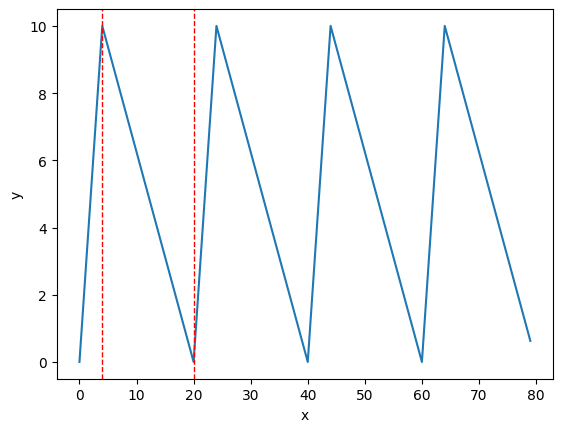

In [63]:
""" Du trenger ikke ha med dette Johannes"""

# Prøver å forstå alt sammen. Tegner potensialet.
# Må modifisere litt. Kan ikke sammenligne et helt array med periode, siden hver verdi for forskjellig bool-verdi.

alfa = 0.2
def V1_test(x):
    potensialer = np.zeros_like(x, dtype = float)    # Viktig å endre datatype. Hvis ikke blir verdiene til int.
    for i in range(len(x)):
        Hvor_i_periode = x[i] % params4a["Nx"]
        if Hvor_i_periode <= alfa*params4a["Nx"]:
            potensialer[i] = 10*Hvor_i_periode / (alfa* params4a["Nx"])
        else:
            potensialer[i] = -10*(Hvor_i_periode - params4a["Nx"])/((1-alfa)*params4a["Nx"]) 
    return potensialer
    
x_axis = np.arange(0, params4a["L"], 1)
y_potential = V1_test(x_axis)
plt.plot(x_axis, V1_test(x_axis))
plt.xlabel("x")
plt.ylabel("y")
plt.axvline(x=4, color='red', linestyle='--', linewidth=1, label='x=2')
plt.axvline(x=20, color='red', linestyle='--', linewidth=1, label='x=20')
plt.show()

In [ ]:
# Optimalisering. Siden partiklene bare kan bevege steg med lengde 1,
# så behøver vi bare å sjekke forrige/neste partikkel.
# Bruker OMG-metoden. vi lagrer bare plasseringen til partiklene sin venstre posisjon, og sjekker denne+-size for å sjekke om det blir kollisjon.

def enSimulasjon_4a(params):
    collision = False
    particlePos = params["initPosition"].copy()
    print(particlePos)
    Np = params["Np"]
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    b = params["b"]
    tabell_V1_p_pos, tabell_V1_p_neg = params4a["tabell_V1_p_pos"], params4a["tabell_V1_p_neg"]
    tabell_V2_p_pos, tabell_V2_p_neg = params4a["tabell_V2_p_pos"], params4a["tabell_V2_p_neg"]

    positionsOverTime = []
    queue = list(range(Np))

    # optimalisering. Random array
    rng = np.random.default_rng()
    random_values = rng.random(timeSteps*Np)

    positionsOverTime.append(particlePos.copy())

    for k in range(timeSteps):
        random.shuffle(queue)
        whichPotential = ( k // Tp) % 2    
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:

            tilfeldigtall = random_values[Np*k + index]       #Genererer først tilfeldige tall
            x = particlePos[index]
            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if ((x-1) % L) == (((particlePos[(index-1)% Np]) + b) % L):
                    continue
                x -= 1

            elif tilfeldigtall >= (1 - tabell_p_pos[x % L]):
                if (((x+1) + b) % L) == ((particlePos[(index+1) % Np]) % L):
                    continue
                x += 1
            particlePos[index] = x % (L)
            

            if particlePos[0]>60:
                start = 1
            else:
                start = 0
            if particlePos[-1]<40:
                slutt = -2
            else:
                slutt = -1

            for j in range(start, slutt):
                if particlePos[j+1] < particlePos[j] + b:
                    print("CollisionWarning!!")
                    collision = True

        positionsOverTime.append(particlePos.copy())
    return positionsOverTime

In [65]:
def plotPositions(params):
    positions_over_time = enSimulasjon_4a(params4a)
    print(positions_over_time[0])
    num_balls = len(positions_over_time[0])
    Tp = params["Tp"]
    L = params["L"]

    # Create frames
    frames = []
    for t, positions in enumerate(positions_over_time):
        whichPotential = ( t // Tp) % 2
        if whichPotential == 0:
            potensial = "Sagtann"
            frames.append(
                go.Frame(
                    data=[
                        go.Scatter(
                            x=positions,
                            y=[y_potential[coord] for coord in positions],
                            mode="markers",
                            marker=dict(size=12, symbol = "star"),
                            # mode = "text",
                            # text= "🚀",
                            # textfont=dict(size=20),
                            # name = "Random walk paritcles"
                        )
                    ],
                    layout= go.Layout(
                        annotations=[
                            dict(
                                text=f"Frame: {t}, potensial = {potensial}",
                                x=0.95,
                                y=0.95,
                                xref = "paper",
                                yref = "paper",
                                showarrow = False,
                                font=dict(size=20)
                            )
                        ]
                    ),
                    name=str(t)
                )
            )
        
        else:
            potensial = "flatt"
            frames.append(
                go.Frame(
                    data=[
                        go.Scatter(
                            x=positions,
                            y=[0]*num_balls,
                            mode="markers", 
                            marker=dict(size=12, symbol = "square")

                        )
                    ],
                    layout= go.Layout(
                        annotations=[
                            dict(
                                text=f"Frame: {t}, potensial = {potensial}",
                                x=0.95,
                                y=0.95,
                                xref = "paper",
                                yref = "paper",
                                showarrow = False,
                                font=dict(size=20)
                            )
                        ]
                    ), 
                    name=str(t)
                )
        )



    # Initial figure
    fig = go.Figure(
        data=[
            go.Scatter(
                x=positions_over_time[0],
                y=[0]* num_balls,
                mode="markers",
                marker=dict(size=12)
            )
        ],
        frames=frames
    )


    fig.update_layout(
        title = f'Antall partikler = {num_balls}, størrelse = {params4a["b"]}.'
    )

    # Add slider (frame counter)
    fig.update_layout(
        sliders=[{
            "currentvalue": {"prefix": "Frame: "},
            "steps": [
                {
                    "args": [[f.name], {"frame": {"duration": 50, "redraw": True},
                                        "mode": "immediate"}],
                    "label": f.name,
                    "method": "animate"
                }
                for f in frames
            ]
        }]
    )

    # Add play button
    fig.update_layout(
        xaxis=dict(range=[0, L], title="Position"),
        yaxis=dict(range=[-10, 20]),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[None, {"frame": {"duration": 200, "redraw": True},
                                    "fromcurrent": True}]
                    )
                ]
            )
        ]
    )

    # Potential curve
    fig.add_trace(
        go.Scatter(
            x=x_axis,
            y= y_potential if whichPotential == 0 else 0,
            mode="lines",
            name="Potential"
        )
    )

    fig.show()

In [66]:
plotPositions(params4a)

[0, 8, 16, 24, 32, 40, 48, 56, 64, 73]
[0, 8, 16, 24, 32, 40, 48, 56, 64, 73]


#### Oppgave 4b)

Legger inn flere funksjoner

In [24]:
def rho(params, Np = False):
    if Np == False:
        particleCount = params["Np"]
    else:
        particleCount = Np
    return params["b"]*particleCount/(params["Ns"]*params["Nx"])


In [25]:
params4b = {
    "beta_k"  : 1000,
    "Nx"      : 100,
    "Tp"      : 300,
    "Ns"      : 10,
    "alfa"    : 0.2,
    "b"       : 20,   # Størrelse på partiklene.
    "Nc"      : 100,  # Antall sykler. For hver tetthet.
    "Np"      : 0 # Denne skal varieres for å danne forskjellige tetthet rho.
}
params4b["L"] = 4*params4b["Nx"]
params4b["timeSteps"] = params4b["Tp"]*params4b["Nc"]   #Blir dette riktig
# params4b["rho"] = rho(params4b["b"], params4b["Np"],params4b["Ns"],params4b["Nc"])
# params4b["initPositions"] = MakeParticles(params4b)  Denne må lages i funksjonen

params4b["tabell_V1_p_pos"], params4b["tabell_V1_p_neg"] = lookUpTabell_V1(params4b)
params4b["tabell_V2_p_pos"], params4b["tabell_V2_p_neg"] = lookUpTabell_V2(params4b)

In [26]:
def particleCurrent_sim(params):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    size = params["b"]
    tabell_V1_p_pos, tabell_V1_p_neg = params4b["tabell_V1_p_pos"], params4b["tabell_V1_p_neg"]
    tabell_V2_p_pos, tabell_V2_p_neg = params4b["tabell_V2_p_pos"], params4b["tabell_V2_p_neg"]
    particlePos = params["initPosition"].copy()
    particleCurrent = np.zeros(timeSteps)
    n_pos = 0
    n_neg = 0

    queue = list(range(Np))

    # optimalisering. Random array
    rng = np.random.default_rng()
    random_values = rng.random(timeSteps*Np)

    for k in range(timeSteps):
        random.shuffle(queue)
        whichPotential = ( k // Tp) % 2
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:
            tilfeldigtall = random_values[Np*k + index]       #Genererer først tilfeldige tall
            x = particlePos[index]


            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if (x-1) == ((particlePos[index-1] + size) % L):
                    continue
                x -= 1
                n_neg += 1
            elif tilfeldigtall >= (1 - tabell_p_pos[x % L]):
                if (x+1) == ((particlePos[(index+1) % Np] -size) % L):
                    continue
                x += 1
                n_pos += 1
            particlePos[index] = x % (L)            
        particleCurrent[k] = (n_pos - n_neg)/Np

    averageCurrent = np.sum(particleCurrent)/len(particleCurrent)
    
    return averageCurrent

In [27]:
def Oppgave4b(params):
    minNp = 1
    maxNp = int(params["Nx"]*params["Ns"]/params["b"])
    Np = np.arange(minNp, maxNp, 1)
    rhoList = np.zeros(len(Np))
    averageCurrentList = np.zeros(len(Np))

    plt.xlabel("Particle density")
    plt.ylabel("Average Current")

    for i in range(len(Np)):
        params["Np"] = Np[i]
        params["initPosition"] = MakeParticles(params)
        averageCurrent = particleCurrent_sim(params)
        rhoList[i] = (rho(params, Np[i]))
        averageCurrentList[i] = averageCurrent

    plt.plot(rhoList, averageCurrentList, label = "Plotting average current")
    plt.show()


        

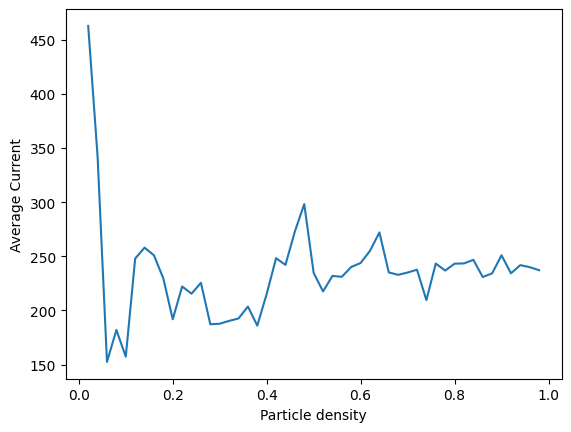

In [28]:
Oppgave4b(params4b)